# Trabalho 2 — Image Captioning com Atenção

Neste trabalho, você vai construir um sistema de **geração automática de legendas** para imagens (*image captioning*).

A arquitetura combina:
- Um **encoder visual** baseado em CNN (ResNet ou VGG) que extrai mapas de características da imagem;
- Um **decoder textual** baseado em LSTM que gera texto palavra a palavra;
- Uma camada de **atenção** que, a cada passo da geração, permite ao decoder focar em diferentes regiões da imagem.

Esta é a arquitetura do artigo clássico [Show, Attend and Tell (Xu et al., 2015)](https://arxiv.org/abs/1502.03044).

**Objetivos:**
- Construir um pipeline completo de image captioning;
- Entender como encoders visuais e decoders textuais se conectam;
- Investigar o papel da atenção na geração de texto;
- Avaliar os resultados gerados.

**Entregáveis:**
1. Este notebook preenchido e executado;
2. Os pesos do melhor modelo;
3. Respostas curtas nas células de texto;
4. Tabelas e figuras pedidos ao longo do trabalho.

**Regras gerais:**
- Use **PyTorch**.
- Não apague células do enunciado.
- Use o conjunto de **teste** apenas na avaliação final.

## Parte 0 — Setup e reprodutibilidade

In [3]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'torch: {torch.__version__}')
print(f'device: {DEVICE}')

student_run_tag = 'dcp_28_04'  # substitua por suas iniciais + data

torch: 2.5.1+cu121
device: cuda


In [4]:
# sanity check
assert student_run_tag != 'SEU_TAG_AQUI', 'Substitua student_run_tag por suas iniciais + data'

## Parte 1 — Dataset: Flickr8k

Usaremos o **Flickr8k**, um dataset padrão para image captioning:
- **8.000 imagens** fotográficas variadas;
- **5 legendas por imagem**, escritas por humanos;
- Legendas curtas (média ~11 palavras);
- Split oficial: 6.000 treino / 1.000 validação / 1.000 teste.

### 1.1 Carregar o dataset

In [5]:
from datasets import load_dataset # from Hugging Face Datasets
import os

DATASET = 'flickr8k'  # ou 'flickr30k'

# Criar diretório de cache para os datasets do Hugging Face, 
# para evitar baixar os dados toda vez
cache_dir = os.path.abspath(f'../data/{DATASET}_cache')
os.makedirs(cache_dir, exist_ok=True)

raw = {}
for split in ['train', 'validation', 'test']:
    if DATASET == 'flickr8k':
        raw[split] = load_dataset('jxie/flickr8k', split=split, cache_dir=cache_dir)
    else:
        _ds = load_dataset('AnyModal/flickr30k', split=split, cache_dir=cache_dir)
        # Expand list captions → caption_0 … caption_4 (required by downstream code)
        raw[split] = _ds.map(lambda ex: {f'caption_{i}': c for i, c in enumerate(ex['original_alt_text'])})

print('Train:     ', len(raw['train']), 'images')
print('Validation:', len(raw['validation']), 'images')
print('Test:      ', len(raw['test']), 'images')


/mnt/storage_C1/Daniel_Couto/git_curso/ml2_trabalhos_2026/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train:      6000 images
Validation: 1000 images
Test:       1000 images


### 1.2 Visualizar amostras

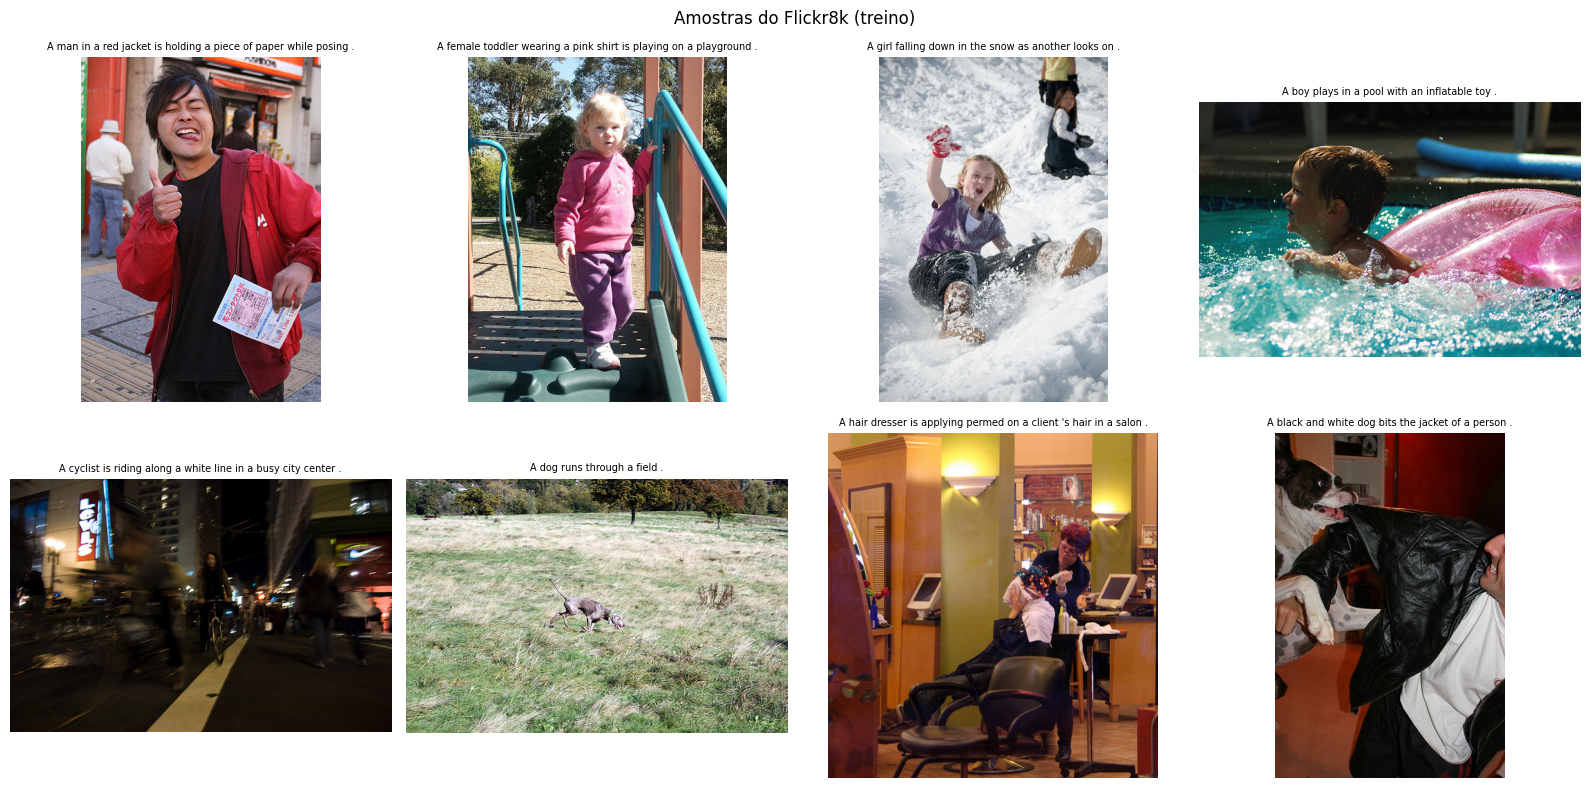

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
indices = random.sample(range(len(raw['train'])), 8)

for ax, idx in zip(axes.flat, indices):
    sample = raw['train'][idx]
    ax.imshow(sample['image'])
    ax.set_title(sample['caption_0'], fontsize=7, wrap=True)
    ax.axis('off')

plt.suptitle('Amostras do Flickr8k (treino)', fontsize=12)
plt.tight_layout()
plt.show()

### 1.3 Inspecionar legendas

In [7]:
sample = raw['train'][0]
print('Tamanho original da imagem:', sample['image'].size)
print()
for i in range(5):
    caption = sample[f'caption_{i}']
    print(f'  caption_{i} ({len(caption.split())} palavras): {caption}')

Tamanho original da imagem: (500, 399)

  caption_0 (13 palavras): A black dog is running after a white dog in the snow .
  caption_1 (7 palavras): Black dog chasing brown dog through snow
  caption_2 (10 palavras): Two dogs chase each other across the snowy ground .
  caption_3 (8 palavras): Two dogs play together in the snow .
  caption_4 (11 palavras): Two dogs running through a low lying body of water .


Vamos analisar as legendas para entender a distribuição de palavras, o comprimento médio, etc. Isso nos ajudará a escolher hiperparâmetros como o tamanho do vocabulário e o comprimento máximo das legendas.

Total de legendas (treino): 30000
Comprimento médio:  11.8 palavras
Desvio padrão:      3.9
Mínimo / Máximo:    2 / 38
Percentil 95:       19 palavras


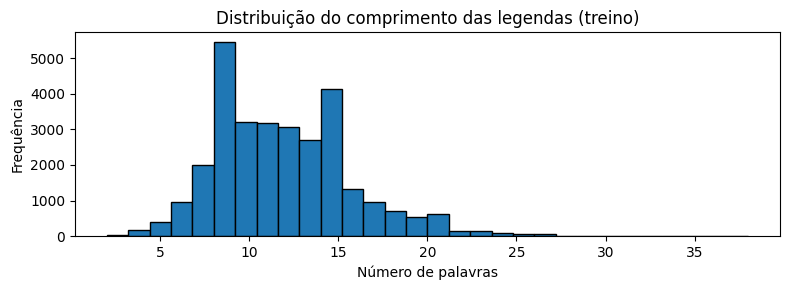

In [8]:
# Estatísticas de comprimento das legendas
all_captions = []
for sample in raw['train']:
    for i in range(5):
        all_captions.append(sample[f'caption_{i}'])

lengths = [len(c.split()) for c in all_captions]
lengths = np.array(lengths)

print(f'Total de legendas (treino): {len(lengths)}')
print(f'Comprimento médio:  {lengths.mean():.1f} palavras')
print(f'Desvio padrão:      {lengths.std():.1f}')
print(f'Mínimo / Máximo:    {lengths.min()} / {lengths.max()}')
print(f'Percentil 95:       {np.percentile(lengths, 95):.0f} palavras')

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=30, edgecolor='black')
plt.xlabel('Número de palavras')
plt.ylabel('Frequência')
plt.title('Distribuição do comprimento das legendas (treino)')
plt.tight_layout()
plt.show()

### 1.4 Vocabulário

Construímos o vocabulário a partir das legendas de **treino** apenas.

Tokens especiais:
- `<PAD>` — preenchimento para batches de tamanho fixo  
- `<SOS>` — início de sequência (*start of sentence*)  
- `<EOS>` — fim de sequência (*end of sentence*)  
- `<UNK>` — palavra desconhecida (fora do vocabulário)

In [9]:
from collections import Counter
import re

MIN_FREQ = 5  # palavras com frequência abaixo disso viram <UNK>

PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
UNK_TOKEN = '<UNK>'

def _tokenize_str(caption: str) -> list[str]:
    """Tokeniza: minúsculas + regex — remove pontuação, mantém apenas letras."""
    return re.findall(r"[a-z]+", caption.lower())

counter = Counter()
for caption in all_captions:
    counter.update(_tokenize_str(caption))

special_tokens = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
vocab_words = [w for w, freq in counter.most_common() if freq >= MIN_FREQ]
vocab = special_tokens + vocab_words

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

PAD_IDX = word2idx[PAD_TOKEN]
SOS_IDX = word2idx[SOS_TOKEN]
EOS_IDX = word2idx[EOS_TOKEN]
UNK_IDX = word2idx[UNK_TOKEN]

VOCAB_SIZE = len(vocab)
print(f'Palavras únicas totais:     {len(counter)}')
print(f'Palavras com freq >= {MIN_FREQ}:   {len(vocab_words)}')
print(f'Tamanho do vocabulário:     {VOCAB_SIZE}  (incluindo tokens especiais)')

Palavras únicas totais:     7333
Palavras com freq >= 5:   2529
Tamanho do vocabulário:     2533  (incluindo tokens especiais)


In [10]:
def tokenize(caption: str) -> list[int]:
    """Converte uma string em lista de índices, com SOS e EOS."""
    tokens = [SOS_IDX]
    tokens += [word2idx.get(w, UNK_IDX) for w in _tokenize_str(caption)]
    tokens += [EOS_IDX]
    return tokens

def detokenize(indices: list[int]) -> str:
    """Converte lista de índices de volta em string, filtrando tokens especiais."""
    words = []
    for idx in indices:
        if idx == EOS_IDX:
            break
        if idx not in (SOS_IDX, PAD_IDX, UNK_IDX):  # UNK filtrado para não contaminar saída
            words.append(idx2word.get(idx, UNK_TOKEN))
    return ' '.join(words)

# Sanidade
ex = all_captions[0]
print('Original: ', ex)
print('Tokens:   ', tokenize(ex))
print('Decoded:  ', detokenize(tokenize(ex)))

Original:  A black dog is running after a white dog in the snow .
Tokens:    [1, 4, 16, 10, 8, 33, 258, 4, 15, 10, 5, 6, 43, 2]
Decoded:   a black dog is running after a white dog in the snow


### Questão 1 — Vocabulário e Tokenização

**a)** O vocabulário é construído com frequência mínima `MIN_FREQ = 5`. Explique o trade-off envolvido nessa escolha: o que acontece com palavras raras quando `MIN_FREQ` é muito alto? E quando é muito baixo? Qual o impacto no tamanho da camada de *embedding* e na capacidade do modelo de descrever objetos incomuns?

**b)** A função `detokenize` filtra o token `<UNK>` da legenda produzida, mas a função `tokenize` o insere ao codificar palavras fora do vocabulário. Qual é a justificativa para essa assimetria? O que aconteceria com o BLEU score se `<UNK>` fosse mantido na saída gerada pelo modelo?

**c)** O vocabulário é construído **somente** a partir das legendas de treinamento, nunca das de validação ou teste. Por que isso é importante para uma avaliação honesta do modelo? O que poderia acontecer se incluíssemos os dados de validação/teste na contagem de frequências?

**Respostas:**

**a)** A ideia é que se você colocar um valor muito alto, o vocabulário fica enxuto e o modelo treina rápido, mas ele não aprende para palavras específicas e começa a chamar tudo de "desconhecido". Se colocar um valor muito baixo, o vocabulário explode e o modelo pode tentar decorar palavras que aparecem uma única vez, o que causa ruído e gasta memória à toa na camada de embedding. No fim, o modelo acaba preferindo termos genéricos em vez de descrever detalhes raros.

**b)** O modelo precisa desse token na hora de codificar as frases para não travar quando encontrar uma palavra que ele não conhece. Mas, na hora de escrever a legenda (decodificar), a gente limpa o <UNK> para não ficar uma sentença com buracos no meio. Se deixássemos o token na saída, o BLEU score ia despencar, já que as legendas de referência feitas por humanos não têm esse token, e o cálculo de precisão ia considerar o <UNK> como um erro crasso.

**c)** Se você olha as palavras do teste para montar o vocabulário, é um vazamento para o treino. O teste tem que ser um território totalmente desconhecido para vermos se o modelo realmente aprendeu a generalizar ou se só decorou o que viu antes. Se incluíssemos tudo, o desempenho seria muito bom no treino, mas teria um desempenho pior em imagens realmente novas para ele.

### 1.5 Dataset e DataLoader PyTorch

Cada imagem possui 5 legendas. Para o treinamento, expandimos o dataset para que cada par (imagem, legenda) seja um exemplo separado.

### Questão 2 — Dataset e DataLoader

**a)** No `collate_fn`, a função `pad_sequence` alinha legendas de comprimentos diferentes dentro de um batch usando `padding_value=PAD_IDX`. Por que esse valor específico e não simplesmente `0`? Como a função de perda (`CrossEntropyLoss`) lida com esses tokens de padding para que eles não influenciem o gradiente?

**b)** O `Flickr8kDataset` expande o dataset para `num_imagens × 5` exemplos, um por legenda. Uma mesma imagem aparece 5 vezes no conjunto de treino com legendas diferentes. Isso pode causar algum tipo de *data leakage* entre treino e validação? Justifique levando em conta como os splits do Flickr8k são definidos.

**Respostas:**

**a)**  A gente usa o PAD_IDX porque ele é o "ID oficial" do padding definido no seu vocabulário. Mesmo que ele seja zero em muitos casos, usar a variável garante que o modelo não se confunda se a organização do vocabulário mudar. Na hora de calcular o erro, a CrossEntropyLoss tem um parâmetro chamado ignore_index. Quando passamos o PAD_IDX ali, a função de perda simplesmente ignora esses tokens na hora do cálculo. Assim, o modelo não é "punido" nem "premiado" por acertar ou errar o preenchimento, e o gradiente não é afetado por algo que não faz parte da frase real.

**b)** Não acontece data leakage porque o corte entre treino, validação e teste é feito pelas imagens e não pelas legendas soltas. Ou seja, se a "imagem_do_cachorro.jpg" está no treino, todas as 5 legendas dela vão estar no treino também. Ela nunca vai aparecer na validação com uma legenda diferente. Como o modelo nunca viu aquela imagem específica (nem nenhuma de suas legendas) durante o treinamento, a avaliação continua sendo justa.

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as T

IMG_SIZE = 256  # imagens redimensionadas para IMG_SIZE x IMG_SIZE

# Normalização padrão ImageNet (usada pela ResNet pré-treinada)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Inversa da normalização ImageNet — usada para visualização
unnorm = T.Compose([
    T.Normalize(mean=[0, 0, 0], std=[1 / s for s in IMAGENET_STD]),
    T.Normalize(mean=[-m for m in IMAGENET_MEAN], std=[1, 1, 1]),
])

class Flickr8kDataset(Dataset):
    def __init__(self, hf_dataset, transform=None, num_captions=5):
        self.data = hf_dataset
        self.transform = transform
        self.num_captions = num_captions
        # Cada imagem aparece num_captions vezes
        self.length = len(self.data) * num_captions

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        img_idx = idx // self.num_captions
        cap_idx = idx % self.num_captions
        sample = self.data[img_idx]
        img = sample['image'].convert('RGB')
        if self.transform:
            img = self.transform(img)
        caption_str = sample[f'caption_{cap_idx}']
        caption_ids = torch.tensor(tokenize(caption_str), dtype=torch.long)
        return img, caption_ids


def collate_fn(batch):
    """Agrupa imagens e legends num batch, aplicando padding nas legendas."""
    images, captions = zip(*batch)
    images = torch.stack(images)
    # pad_sequence espera (seq_len, batch) por padrão — usamos batch_first=True
    captions = pad_sequence(captions, batch_first=True, padding_value=PAD_IDX)
    return images, captions


BATCH_SIZE = 32

train_ds = Flickr8kDataset(raw['train'],      transform=train_transform)
val_ds   = Flickr8kDataset(raw['validation'], transform=eval_transform)
test_ds  = Flickr8kDataset(raw['test'],       transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=False)

print(f'Exemplos no treino:     {len(train_ds)}  ({len(raw["train"])} imagens × 5)')
print(f'Batches por época:      {len(train_loader)}')
print(f'Exemplos na validação:  {len(val_ds)}')
print(f'Exemplos no teste:      {len(test_ds)}')

Exemplos no treino:     30000  (6000 imagens × 5)
Batches por época:      938
Exemplos na validação:  5000
Exemplos no teste:      5000


In [15]:
# Verificar formato de um batch
imgs, caps = next(iter(train_loader))
print('Batch de imagens:', imgs.shape)    # (B, 3, 256, 256)
print('Batch de legendas:', caps.shape)  # (B, T_max)
print('Exemplo de legenda decodificada:', detokenize(caps[0].tolist()))

Batch de imagens: torch.Size([32, 3, 256, 256])
Batch de legendas: torch.Size([32, 20])
Exemplo de legenda decodificada: a man wearing a black shirt and brown pants skates on a concrete surface near a park bench


## Parte 2 — Encoder Visual (CNN)

O encoder transforma uma imagem `(3, H, W)` em um conjunto de vetores de características espaciais `(num_pixels, encoder_dim)`, onde cada vetor descreve uma **região** da imagem.

Usamos uma **ResNet50 pré-treinada** no ImageNet e cortamos após as primeiras `N` camadas residuais. O parâmetro `N` controla o trade-off entre resolução espacial e riqueza semântica dos features:

| N | Camadas usadas | Saída (256×256 input) | Regiões |
|---|---|---|---|
| 1 | stem + layer1 | (B, 256, 64, 64) | 4096 |
| 2 | stem + layer1-2 | (B, 512, 32, 32) | 1024 |
| 3 | stem + layer1-3 | (B, 1024, 16, 16) | 256 |
| 4 | stem + layer1-4 | (B, 2048, 8, 8) | 64 |

Uma **projeção linear** mapeia os features para `encoder_dim` fixo, facilitando a conexão com o decoder independentemente de `N`.

A saída final tem shape `(B, num_pixels, encoder_dim)`, onde cada uma das `num_pixels` posições é um vetor que descreve aquela região da imagem.

### 2.1 Implementação do ImageEncoder

In [16]:
import torch.nn as nn
import torchvision.models as models

# Hiperparâmetro: quantas camadas residuais usar (1, 2, 3 ou 4)
CNN_LAYERS = 3      # N=3 → (B, 1024, 16, 16) → 256 regiões por imagem
ENCODER_DIM = 512   # dimensão uniforme de saída após projeção


class ImageEncoder(nn.Module):
    """
    Encoder visual baseado nos primeiros N blocos residuais de uma ResNet50
    pré-treinada.

    Entrada:  (B, 3, H, W)
    Saída:    (B, num_pixels, encoder_dim)
              onde num_pixels = H' * W' depende de CNN_LAYERS
    """

    # Canais de saída para cada N (após o stem da ResNet50)
    _out_channels = {1: 256, 2: 512, 3: 1024, 4: 2048}

    def __init__(self, cnn_layers: int = CNN_LAYERS, encoder_dim: int = ENCODER_DIM,
                 fine_tune: bool = False):
        super().__init__()
        assert cnn_layers in (1, 2, 3, 4), "cnn_layers deve ser 1, 2, 3, ou 4"

        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Stem: conv1 + bn1 + relu + maxpool
        self.stem = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool
        )

        # Blocos residuais até N
        self.res_layers = nn.ModuleList()
        for i in range(1, cnn_layers + 1):
            self.res_layers.append(getattr(resnet, f'layer{i}'))

        # Projeção para encoder_dim uniforme
        in_channels = self._out_channels[cnn_layers]
        self.proj = nn.Sequential(
            nn.Conv2d(in_channels, encoder_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(encoder_dim),
            nn.ReLU(inplace=True),
        )

        # Congela os pesos pré-treinados por padrão
        self._set_fine_tune(fine_tune)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Passe a imagem pelo stem, blocos residuais e projeção.

        Args:
            x: (B, 3, H, W)
        Returns:
            (B, num_pixels, encoder_dim)  com num_pixels = H' * W'
        """
        # TODO: Implemente o forward pass do encoder.
        # 1. Passe x pelo self.stem
        # 2. Passe x por cada layer em self.res_layers (sequencialmente)
        # 3. Aplique self.proj → (B, encoder_dim, H', W')
        # 4. Reordene com permute e reshape para (B, num_pixels, encoder_dim)
        raise NotImplementedError("Implemente ImageEncoder.forward()")

    def train(self, mode: bool = True):
        super().train(mode)
        for module in [self.stem, *self.res_layers]:
            if not any(p.requires_grad for p in module.parameters()):
                module.eval()
        return self
    
    def _set_fine_tune(self, fine_tune: bool):
        for p in self.stem.parameters():
            p.requires_grad = fine_tune
        for layer in self.res_layers:
            for p in layer.parameters():
                p.requires_grad = fine_tune
        # A projeção é sempre treinável
        for p in self.proj.parameters():
            p.requires_grad = True

### Questão 3 — Design do Encoder

**a)** Explique o papel do método `train()` customizado no `ImageEncoder`. O que acontece se não o implementarmos? Dê um exemplo concreto de módulo que se comportaria de forma inesperada durante o treinamento caso essa sobrescrita não existisse.

**b)** Qual é o papel da projeção linear `self.proj` (Conv2d 1×1 + BN + ReLU) ao final do encoder? O que aconteceria com o mecanismo de atenção se a removêssemos e conectássemos diretamente os mapas do último bloco residual — considerando, por exemplo, a passagem de `N=1` para `N=4`?

**Respostas:**

**a)** O papel desse train() customizado no ImageEncoder é garantir que o encoder fique sempre em modo de avaliação (eval()), mesmo quando o resto do modelo estiver em modo de treino. A gente faz isso porque, nesse trabalho, usamos uma CNN pré-treinada como um extrator de características fixo. Se a gente não implementasse essa sobrescrita, ao rodar model.train(), o encoder também entraria em modo de treino. O exemplo concreto de problema aqui é o BatchNorm: se ele entrar em modo de treino, vai tentar atualizar suas estatísticas (média e variância) com base nos seus dados de treino, o que bagunçaria os pesos pré-treinados e pioraria a extração de características que já veio pronta.

**b)** 

### 2.2 Verificar shapes para cada valor de N

In [ ]:
dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)

print(f"{'N':>3}  {'Saída do encoder':>30}  {'num_pixels':>12}  {'params treináveis':>18}")
print('-' * 70)
for n in [1, 2, 3, 4]:
    enc = ImageEncoder(cnn_layers=n, encoder_dim=ENCODER_DIM)
    enc.eval()
    with torch.no_grad():
        out = enc(dummy)
    trainable = sum(p.numel() for p in enc.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in enc.parameters())
    print(f"{n:>3}  {str(tuple(out.shape)):>30}  {out.shape[1]:>12}  {trainable:>14,} / {total:,}")

### 2.3 Visualizar mapas de features com PCA

Para inspecionar o que o encoder captura, projetamos os `encoder_dim` canais em 3 dimensões via PCA e exibimos como uma imagem RGB. Cada "cor" corresponde a uma direção de variação no espaço de features.

In [ ]:
def feature_map_pca(encoder: ImageEncoder, img_tensor: torch.Tensor) -> np.ndarray:
    """
    Extrai o mapa de features e reduz para 3 componentes PCA para visualização.
    Retorna um array (H', W', 3) normalizado em [0, 1].
    """
    encoder.eval()
    with torch.no_grad():
        feats = encoder(img_tensor.unsqueeze(0))  # (1, num_pixels, encoder_dim)
    feats = feats.squeeze(0).numpy()               # (num_pixels, encoder_dim)
    H = W = int(feats.shape[0] ** 0.5)

    # PCA manual com SVD
    feats_centered = feats - feats.mean(axis=0)
    _, _, Vt = np.linalg.svd(feats_centered, full_matrices=False)
    pca3 = feats_centered @ Vt[:3].T              # (num_pixels, 3)

    # Normaliza cada componente para [0, 1]
    pca3 -= pca3.min(axis=0)
    pca3 /= pca3.max(axis=0) + 1e-8
    return pca3.reshape(H, W, 3)


# Escolhe 4 imagens de amostra
sample_imgs = [eval_transform(raw['train'][i]['image'].convert('RGB')) for i in range(4)]
sample_captions = [raw['train'][i]['caption_0'] for i in range(4)]

encoder = ImageEncoder(cnn_layers=CNN_LAYERS, encoder_dim=ENCODER_DIM)

fig, axes = plt.subplots(4, 3, figsize=(10, 14))
for row, (img_t, cap) in enumerate(zip(sample_imgs, sample_captions)):
    # Imagem original
    img_np = unnorm(img_t).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(cap, fontsize=7, wrap=True)
    axes[row, 0].axis('off')

    # Features com N=CNN_LAYERS
    pca = feature_map_pca(encoder, img_t)
    axes[row, 1].imshow(pca)
    axes[row, 1].set_title(f'PCA features  N={CNN_LAYERS}\n({int(pca.shape[0])}×{int(pca.shape[1])} regiões)', fontsize=7)
    axes[row, 1].axis('off')

    # Features com N=4 para comparar
    enc4 = ImageEncoder(cnn_layers=4, encoder_dim=ENCODER_DIM)
    pca4 = feature_map_pca(enc4, img_t)
    axes[row, 2].imshow(pca4)
    axes[row, 2].set_title(f'PCA features  N=4\n({int(pca4.shape[0])}×{int(pca4.shape[1])} regiões)', fontsize=7)
    axes[row, 2].axis('off')

plt.suptitle('Imagem original vs. PCA do mapa de features', fontsize=11)
plt.tight_layout()
plt.show()

### Questão 4 — Trade-off resolução vs. semântica

Olhando a visualização PCA, compare o encoder com `N=CNN_LAYERS` e `N=4`:

- O que você observa em relação à resolução espacial dos mapas?
- Com `N` maior, as regiões ficam mais ou menos "semânticas" (capturam objetos inteiros vs. texturas/bordas)?
- Qual valor de `N` você escolheria para conectar com o mecanismo de atenção? Justifique.

*Escreva sua resposta aqui.*

In [ ]:
# ── Caching de features do encoder (opcional — acelera treino quando encoder congelado) ──
#
# Quando CACHE_ENCODER_FEATURES=True, o encoder é executado uma única vez sobre todas as
# imagens e os features são armazenados em disco como um .pt keyed por (CNN_LAYERS,
# ENCODER_DIM, IMG_SIZE). Nas épocas seguintes o encoder é pulado completamente.
#
# Incompatibilidades (verificadas abaixo):
#   • FINE_TUNE_ENCODER=True  → features mudariam durante treino (verificado em célula 5.2)
#   • RandomHorizontalFlip    → cache usa sempre eval_transform (aviso impresso abaixo)

CACHE_ENCODER_FEATURES = False  # mude para True para ativar o cache

if CACHE_ENCODER_FEATURES:
    _has_flip = any(isinstance(t, T.RandomHorizontalFlip)
                    for t in train_transform.transforms)
    if _has_flip:
        print("AVISO: RandomHorizontalFlip detectado — cache usa eval_transform para treino "
              "(sem flip). Defina CACHE_ENCODER_FEATURES=False para usar augmentation.")

    _cache_key = f"encoder_cache_L{CNN_LAYERS}_D{ENCODER_DIM}_S{IMG_SIZE}.pt"

    if not os.path.exists(_cache_key):
        _enc_cache = ImageEncoder(cnn_layers=CNN_LAYERS, encoder_dim=ENCODER_DIM).to(DEVICE)
        _enc_cache.eval()
        _cache_dict = {}
        for _sname, _sraw in [('train', raw['train']),
                               ('val',   raw['validation']),
                               ('test',  raw['test'])]:
            print(f'Computando features de {_sname} ({len(_sraw)} imagens)...')
            _feats_list = []
            with torch.no_grad():
                for _i in range(len(_sraw)):
                    _img_t = eval_transform(_sraw[_i]['image'].convert('RGB'))
                    _f = _enc_cache(_img_t.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
                    _feats_list.append(_f)
            _cache_dict[_sname] = torch.stack(_feats_list)
        torch.save(_cache_dict, _cache_key)
        print(f'Features salvas em: {_cache_key}')
        del _enc_cache
    else:
        print(f'Carregando features do cache: {_cache_key}')

    _cached_feats = torch.load(_cache_key, map_location='cpu')

    class CachedFlickr8kDataset(Dataset):
        """Dataset que retorna features pré-computadas no lugar de imagens brutas."""
        def __init__(self, hf_dataset, feats_tensor, num_captions=5):
            self.data          = hf_dataset
            self.feats         = feats_tensor   # (N_imgs, num_pixels, encoder_dim)
            self.num_captions  = num_captions
            self.length        = len(self.data) * num_captions

        def __len__(self):
            return self.length

        def __getitem__(self, idx):
            img_idx     = idx // self.num_captions
            cap_idx     = idx % self.num_captions
            feat        = self.feats[img_idx]   # (num_pixels, encoder_dim)
            caption_str = self.data[img_idx][f'caption_{cap_idx}']
            caption_ids = torch.tensor(tokenize(caption_str), dtype=torch.long)
            return feat, caption_ids

    def _collate_cached(batch):
        feats, captions = zip(*batch)
        feats    = torch.stack(feats)
        captions = pad_sequence(captions, batch_first=True, padding_value=PAD_IDX)
        return feats, captions

    train_loader = DataLoader(
        CachedFlickr8kDataset(raw['train'],      _cached_feats['train']),
        batch_size=BATCH_SIZE, shuffle=True,  collate_fn=_collate_cached,
        num_workers=2, pin_memory=True,
    )
    val_loader = DataLoader(
        CachedFlickr8kDataset(raw['validation'], _cached_feats['val']),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=_collate_cached,
        num_workers=2, pin_memory=True,
    )
    test_loader = DataLoader(
        CachedFlickr8kDataset(raw['test'],       _cached_feats['test']),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=_collate_cached,
        num_workers=2, pin_memory=True,
    )
    print(f'DataLoaders reconfigurados para usar features em cache ({_cache_key}).')

## Parte 3 — LSTM Decoder

O decoder recebe os features do encoder e gera a legenda **palavra a palavra**.  
A cada passo, o `LSTMCell` consome a *embedding* da palavra anterior concatenada com um **vetor de contexto** proveniente da atenção.  
Nesta parte, o vetor de contexto é um **placeholder de zeros** — o mecanismo de atenção real será adicionado na Parte 4.

### 3.1 Hiperparâmetros e implementação

In [ ]:
EMBED_DIM           = 256   # dimensão dos embeddings de palavras
HIDDEN_DIM          = 512   # dimensão do estado oculto do LSTM
NUM_DECODER_LAYERS  = 1     # número de camadas do LSTM
DECODER_DROPOUT     = 0.5   # dropout aplicado entre camadas e na saída


In [ ]:
class LSTMDecoder(nn.Module):
    """
    Decoder textual baseado em LSTM.

    Quando `attention` é fornecido no forward, usa atenção real.
    Caso contrário mantém o placeholder de zeros (compatível com Parte 3).

    Entradas:
        captions:   (B, T)                       — sequência com SOS..EOS
        enc_feats:  (B, num_pixels, encoder_dim) — features do encoder
        attention:  Attention | None

    Saídas:
        logits:  (B, T-1, VOCAB_SIZE)
        alphas:  (B, T-1, num_pixels)
    """

    def __init__(
        self,
        vocab_size:  int   = VOCAB_SIZE,
        embed_dim:   int   = EMBED_DIM,
        hidden_dim:  int   = HIDDEN_DIM,
        encoder_dim: int   = ENCODER_DIM,
        num_layers:  int   = NUM_DECODER_LAYERS,
        dropout:     float = DECODER_DROPOUT,
        pad_idx:     int   = PAD_IDX,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.init_h    = nn.Linear(encoder_dim, hidden_dim)
        self.init_c    = nn.Linear(encoder_dim, hidden_dim)
        self.lstm      = nn.LSTM(
            input_size=embed_dim + encoder_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.dropout   = nn.Dropout(dropout)
        self.fc_out    = nn.Linear(hidden_dim, vocab_size)

    def _init_hidden(self, enc_feats: torch.Tensor):
        mean_feats = enc_feats.mean(dim=1)           # (B, encoder_dim)
        h0 = torch.tanh(self.init_h(mean_feats))     # (B, hidden_dim)
        c0 = torch.tanh(self.init_c(mean_feats))
        # First layer initialized from encoder mean; remaining layers start at zero
        hs = torch.stack([h0] + [torch.zeros_like(h0) for _ in range(self.num_layers - 1)])
        cs = torch.stack([c0] + [torch.zeros_like(c0) for _ in range(self.num_layers - 1)])
        return hs, cs

    def forward(
        self,
        captions:   torch.Tensor,
        enc_feats:  torch.Tensor,
        attention: "Attention | None" = None,
    ):
        """
        Entradas:
            captions:   (B, T)                       — sequência com SOS..EOS
            enc_feats:  (B, num_pixels, encoder_dim) — features do encoder
            attention:  Attention | None
        Saídas:
            logits:  (B, T-1, VOCAB_SIZE)
            alphas:  (B, T-1, num_pixels)
        """
        # TODO: Implemente o forward pass do decoder.
        # 1. Compute embeddings para todos os tokens de captions     → (B, T, embed_dim)
        # 2. Inicialize estados ocultos com self._init_hidden(enc_feats)
        # 3. Para t in range(T - 1):
        #    a. word_emb = embeddings[:, t, :]                        → (B, embed_dim)
        #    b. Se attention não for None: context, alpha = attention(enc_feats, h[-1])
        #       Senão: context = zeros(B, encoder_dim), alpha = zeros(B, num_pixels)
        #    c. Concatene [word_emb, context] e passe pelo self.lstm  → out (B, 1, hidden_dim)
        #    d. Projete com self.fc_out(self.dropout(out.squeeze(1))) → logits (B, vocab_size)
        #    e. Acumule logits e alphas em listas
        # 4. Stack: logits (B, T-1, VOCAB_SIZE), alphas (B, T-1, num_pixels)
        raise NotImplementedError("Implemente LSTMDecoder.forward()")


In [ ]:
# Sanidade: verificar shapes do LSTMDecoder
enc = ImageEncoder(cnn_layers=CNN_LAYERS, encoder_dim=ENCODER_DIM).to(DEVICE)
dec = LSTMDecoder(encoder_dim=ENCODER_DIM).to(DEVICE)
enc.eval()
dec.eval()

B = 4
dummy_imgs = torch.zeros(B, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
dummy_caps = torch.randint(0, VOCAB_SIZE, (B, 15)).to(DEVICE)

with torch.no_grad():
    feats = enc(dummy_imgs)                     # (B, num_pixels, encoder_dim)
    logits, alphas = dec(dummy_caps, feats)     # (B, T-1, VOCAB_SIZE), (B, T-1, num_pixels)

print(f'Encoder output:    {tuple(feats.shape)}')    # (4, 256, 512)
print(f'Decoder logits:    {tuple(logits.shape)}')   # (4, 14, 2549)
print(f'Attention weights: {tuple(alphas.shape)}')   # (4, 14, 256)

assert feats.shape  == (B, 256, ENCODER_DIM),  f"Encoder shape errado: {feats.shape}"
assert logits.shape == (B, 14, VOCAB_SIZE),    f"Logits shape errado: {logits.shape}"
assert alphas.shape == (B, 14, 256),           f"Alphas shape errado: {alphas.shape}"
print('\nTodos os shapes estão corretos!')

### Questão 5 — Inicialização do estado oculto

Por que inicializamos o estado oculto `h` e a célula `c` do LSTM a partir da **média** dos features do encoder, em vez de simplesmente usar vetores de zeros?

Considere também: por que apenas a primeira camada do LSTM é inicializada a partir do encoder, enquanto as camadas superiores partem de zero?

*Escreva sua resposta aqui.*

### 3.2 Arquitetura do LSTMDecoder

O decoder opera **passo a passo**, gerando uma palavra por vez com *teacher forcing* durante o treinamento.

**Inicialização — uma única vez antes do loop:**

```
enc_feats  (B, num_pixels, encoder_dim)
      │
      ▼  mean(dim=1)
 mean_feats  (B, encoder_dim)
      │              │
      ▼              ▼
   init_h         init_c
   Linear         Linear
      │              │
      ▼              ▼
  h₀ (B, H)     c₀ (B, H)
```

**A cada passo t (teacher forcing):**

```
 caption[:, t]        enc_feats
      │                    │
      ▼                    ▼
  Embedding         ← atenção (Parte 4) →
  (B, embed_dim)     context (B, encoder_dim)
      │                    │
      └──────── cat ────────┘
                    │
                    ▼  (B, embed_dim + encoder_dim)
          LSTMCell(hₜ₋₁, cₜ₋₁)  →  hₜ, cₜ
                    │
                    ▼  hₜ  (B, hidden_dim)
                 Dropout
                    │
                    ▼
              fc_out  Linear
                    │
                    ▼
            logits  (B, VOCAB_SIZE)
```

> **Nota:** nesta parte o vetor de contexto é um **placeholder de zeros**. Na Parte 4 ele será substituído pelo vetor de atenção ponderado sobre `enc_feats`.

## Parte 4 — Camada de Atenção

O mecanismo de atenção permite ao decoder **focar em regiões específicas** da imagem a cada passo da geração.  
Em vez de usar um vetor de contexto fixo, a atenção calcula um **vetor de contexto dinâmico** como soma ponderada dos features do encoder, onde os pesos dependem do estado oculto atual do decoder.

### 4.1 Módulo de Atenção (Bahdanau aditivo)

In [ ]:
ATTENTION_DIM = 512  # dimensão do espaço de atenção


class Attention(nn.Module):
    """
    Atenção aditiva (Bahdanau) sobre os features espaciais do encoder.

    forward(encoder_features, hidden_state) →
        context_vector  (B, encoder_dim)
        alpha           (B, num_pixels)
    """

    def __init__(
        self,
        encoder_dim:   int = ENCODER_DIM,
        hidden_dim:    int = HIDDEN_DIM,
        attention_dim: int = ATTENTION_DIM,
    ):
        super().__init__()
        self.encoder_att = nn.Linear(encoder_dim,   attention_dim, bias=False)
        self.decoder_att = nn.Linear(hidden_dim,    attention_dim, bias=False)
        self.full_att    = nn.Linear(attention_dim, 1,             bias=False)
        self.relu        = nn.ReLU()
        self.softmax     = nn.Softmax(dim=1)

    def forward(self, encoder_features: torch.Tensor, hidden_state: torch.Tensor):
        """
        Calcula atenção aditiva (Bahdanau).

        Args:
            encoder_features: (B, num_pixels, encoder_dim)
            hidden_state:     (B, hidden_dim)
        Returns:
            context: (B, encoder_dim)   — média ponderada das features espaciais
            alpha:   (B, num_pixels)    — pesos de atenção (somam 1)
        """
        # TODO: Implemente a atenção aditiva.
        # 1. Projete encoder_features com self.encoder_att  → (B, num_pixels, attention_dim)
        # 2. Projete hidden_state com self.decoder_att      → (B, 1, attention_dim)
        # 3. Some as projeções, aplique self.relu e self.full_att → scores (B, num_pixels, 1)
        # 4. Aplique self.softmax (dim=1) e squeeze          → alpha  (B, num_pixels)
        # 5. context = soma ponderada de encoder_features por alpha → (B, encoder_dim)
        raise NotImplementedError("Implemente Attention.forward()")

In [ ]:
# Sanidade: shapes e propriedades da atenção
_attn_check = Attention(encoder_dim=ENCODER_DIM, hidden_dim=HIDDEN_DIM, attention_dim=ATTENTION_DIM).to(DEVICE)
_enc_check  = ImageEncoder(cnn_layers=CNN_LAYERS, encoder_dim=ENCODER_DIM).to(DEVICE)
_dec_check  = LSTMDecoder(encoder_dim=ENCODER_DIM).to(DEVICE)

B_test     = 4
_imgs_t    = torch.zeros(B_test, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
_caps_t    = torch.randint(0, VOCAB_SIZE, (B_test, 15)).to(DEVICE)

with torch.no_grad():
    feats_t = _enc_check(_imgs_t)                                 # (4, 256, 512)

    # ── Atenção isolada ────────────────────────────────────────────────────
    h_test         = torch.zeros(B_test, HIDDEN_DIM).to(DEVICE)
    ctx_t, alpha_t = _attn_check(feats_t, h_test)

    print('── Attention isolada ──────────────────────────────')
    print(f'  context_vector shape : {tuple(ctx_t.shape)}')       # (4, 512)
    print(f'  alpha shape          : {tuple(alpha_t.shape)}')     # (4, 256)
    print(f'  alpha.sum(dim=1)     : {alpha_t.sum(dim=1).tolist()}')  # ~[1,1,1,1]

    # ── Decoder com atenção real ───────────────────────────────────────────
    logits_t, alphas_t = _dec_check(_caps_t, feats_t, attention=_attn_check)

    print('\n── Decoder com atenção ────────────────────────────')
    print(f'  logits shape  : {tuple(logits_t.shape)}')           # (4, 14, 2549)
    print(f'  alphas shape  : {tuple(alphas_t.shape)}')           # (4, 14, 256)

# ── Assertions ─────────────────────────────────────────────────────────────
assert ctx_t.shape   == (B_test, ENCODER_DIM),          f"context shape errado: {ctx_t.shape}"
assert alpha_t.shape == (B_test, 256),                  f"alpha shape errado: {alpha_t.shape}"
assert logits_t.shape == (B_test, 14, VOCAB_SIZE),      f"logits shape errado: {logits_t.shape}"
assert torch.allclose(
    alpha_t.sum(dim=1), torch.ones(B_test, device=DEVICE), atol=1e-5
), "alphas não somam 1 em num_pixels!"

print('\nTodos os shapes e invariantes estão corretos!')

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# ── Inferência greedy com atenção ────────────────────────────────────────────

def greedy_caption_with_attention(encoder, decoder, attention, img_tensor, max_len=30):
    """
    Greedy search sem teacher forcing.
    Retorna:
        words  : list[str]        — palavras geradas (sem SOS/EOS)
        alphas : (T, num_pixels)  — pesos de atenção por passo
    """
    # TODO: Implemente a decodificação greedy com atenção.
    # 1. Coloque os modelos em modo eval e use torch.no_grad()
    # 2. Encode a imagem: enc_feats = encoder(img_tensor.unsqueeze(0).to(DEVICE))
    #    → (1, num_pixels, encoder_dim)
    # 3. Inicialize os estados do LSTM: hs, cs = decoder._init_hidden(enc_feats)
    # 4. Comece com word_idx = torch.tensor([SOS_IDX], device=DEVICE)
    # 5. Para cada passo até max_len:
    #    a. emb = decoder.embedding(word_idx)                     → (1, embed_dim)
    #    b. ctx, alpha = attention(enc_feats, hs[-1])             → ctx (1, enc_dim), alpha (1, num_pixels)
    #    c. x = cat([emb, ctx], dim=1).unsqueeze(1)              → (1, 1, embed+enc)
    #    d. out, (hs, cs) = decoder.lstm(x, (hs, cs))
    #    e. word_idx = decoder.fc_out(out.squeeze(1)).argmax(dim=1)
    #    f. Se EOS_IDX: pare. Se UNK_IDX: continue sem registrar.
    #    g. Acumule idx2word[pred] em words e alpha.squeeze(0).cpu().numpy() em alphas
    # 6. Retorne words e np.stack(alphas) (ou zeros se alphas vazio)
    raise NotImplementedError("Implemente greedy_caption_with_attention()")


# ── Configurar modelos ───────────────────────────────────────────────────────
_enc  = ImageEncoder(cnn_layers=CNN_LAYERS, encoder_dim=ENCODER_DIM).to(DEVICE)
_attn = Attention().to(DEVICE)
_dec  = LSTMDecoder(encoder_dim=ENCODER_DIM).to(DEVICE)

_sample     = raw['validation'][0]
_img_pil    = _sample['image'].convert('RGB')
_img_tensor = eval_transform(_img_pil)

words, alphas = greedy_caption_with_attention(_enc, _dec, _attn, _img_tensor)
print('Legenda gerada (pesos aleatórios):', ' '.join(words))
print(f'Passos: {len(words)},  alphas shape: {alphas.shape}')

# ── Visualização ─────────────────────────────────────────────────────────────
side   = int(alphas.shape[1] ** 0.5)   # 16 para CNN_LAYERS=3
n_show = min(len(words), 9)
n_cols = 5
n_rows = math.ceil((n_show + 1) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.8 * n_cols, 3.2 * n_rows))
axes = axes.flatten()

img_np = unnorm(_img_tensor).permute(1, 2, 0).clamp(0, 1).numpy()

axes[0].imshow(img_np)
axes[0].set_title('original', fontsize=8)
axes[0].axis('off')

for i in range(n_show):
    ax        = axes[i + 1]
    alpha_map = alphas[i].reshape(side, side)
    alpha_up  = np.array(
        Image.fromarray((alpha_map * 255).astype(np.uint8)).resize(
            (IMG_SIZE, IMG_SIZE), Image.BILINEAR
        )
    ) / 255.0
    ax.imshow(img_np)
    ax.imshow(alpha_up, cmap='hot', alpha=0.55)
    ax.set_title(words[i], fontsize=9, fontweight='bold')
    ax.axis('off')

for ax in axes[n_show + 1:]:
    ax.axis('off')

plt.suptitle('Mapa de atenção por palavra gerada\n(pesos aleatórios — treinar na Parte 5)', fontsize=10)
plt.tight_layout()
plt.show()

### Explicação: Atenção Aditiva (Bahdanau)

A fórmula de atenção implementada segue o estilo **aditivo** de [Bahdanau et al., 2015](https://arxiv.org/abs/1409.0473), adaptado para visão em [Show, Attend and Tell (Xu et al., 2015)](https://arxiv.org/abs/1502.03044):

$$e_{t,i} = \mathbf{v}^\top \operatorname{ReLU}\!\bigl(W_{\text{enc}}\,\mathbf{f}_i + W_{\text{dec}}\,\mathbf{h}_{t-1}\bigr)$$

$$\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_j \exp(e_{t,j})}$$

$$\mathbf{c}_t = \sum_i \alpha_{t,i}\,\mathbf{f}_i$$

onde:
- $\mathbf{f}_i \in \mathbb{R}^{d_{\text{enc}}}$ é o feature do encoder na posição espacial $i$;
- $\mathbf{h}_{t-1} \in \mathbb{R}^{d_{\text{hid}}}$ é o estado oculto do decoder no passo anterior;
- $W_{\text{enc}}, W_{\text{dec}}$ projetam independentemente cada sinal para $\mathbb{R}^{d_{\text{att}}}$;
- $\mathbf{v} \in \mathbb{R}^{d_{\text{att}}}$ é um vetor aprendível que colapsa para o score escalar.

#### Por que adição em vez de produto interno?

O **produto interno** (atenção multiplicativa, Luong et al.) calcula $e_{t,i} = \mathbf{h}_{t-1}^\top \mathbf{f}_i$, exigindo que encoder e decoder compartilhem a **mesma dimensão** e escalem bem juntos — premissa frágil quando as duas partes têm origens arquiteturais diferentes (CNN vs. LSTM).

A **adição** projetada oferece três vantagens:

1. **Flexibilidade de dimensões**: `encoder_dim` e `hidden_dim` podem diferir livremente;
2. **Parâmetros próprios por fonte**: $W_{\text{enc}}$ e $W_{\text{dec}}$ aprendem transformações independentes, permitindo ao modelo ponderar cada sinal de forma distinta;
3. **Não-linearidade**: a ativação ReLU (ou tanh) introduz capacidade para capturar interações não-lineares entre posição espacial e contexto de geração.

### Questão 6 — Análise dos mapas de atenção

Após treinar o modelo (Parte 5), execute novamente a célula de visualização acima para uma imagem da validação.

- Compare o mapa de atenção gerado para a **primeira** palavra com o da **última** palavra da legenda.
- As regiões com maior peso são diferentes entre os dois passos?
- O que isso sugere sobre como o decoder usa a atenção ao longo da geração da sequência?

*Escreva sua resposta aqui.*

### Questão 7 — Mecanismo de Atenção: implementação e alternativas

**a)** Na implementação de `Attention.forward`, o cálculo dos scores pode ser mapeado diretamente às equações da célula anterior. Identifique qual linha de código corresponde a cada uma das três equações ($e_{t,i}$, $\alpha_{t,i}$, $\mathbf{c}_t$). Qual é o papel da `ReLU` no cálculo de $e_{t,i}$ — ela é estritamente necessária para a atenção funcionar?

**b)** Os pesos de atenção `alpha` somam 1 para cada passo de tempo (garantido pelo softmax sobre os pixels). O artigo *Show, Attend and Tell* propõe uma regularização **duplamente estocástica** que também penaliza $\sum_t \alpha_{t,i} \approx 1$ para cada pixel $i$. Qual é a intuição dessa regularização — o que ela incentiva o modelo a fazer? A implementação atual a utiliza?

*Escreva sua resposta aqui.*

## Parte 5 — Modelo Completo e Loop de Treinamento

Nesta parte montamos os três módulos em um único `CaptioningModel`, definimos os otimizadores e executamos o treinamento completo com monitoramento da perda de validação.

### 5.1 CaptioningModel — wrapper unificado

In [ ]:
class CaptioningModel(nn.Module):
    """
    Wrapper que agrupa encoder, atenção e decoder em um único módulo.

    forward(images_or_feats, captions) →
        logits       (B, T-1, VOCAB_SIZE)
        attn_weights (B, T-1, num_pixels)

    Aceita tanto imagens brutas (4-D) quanto features pré-computadas (3-D),
    permitindo o uso do cache de features sem alterar o loop de treinamento.
    """

    def __init__(
        self,
        encoder:   ImageEncoder,
        attention: Attention,
        decoder:   LSTMDecoder,
    ):
        super().__init__()
        self.encoder   = encoder
        self.attention = attention
        self.decoder   = decoder

    def forward(self, images_or_feats: torch.Tensor, captions: torch.Tensor):
        if images_or_feats.dim() == 4:           # imagem bruta → passa pelo encoder
            enc_feats = self.encoder(images_or_feats)
        else:                                     # features pré-computadas (cache ativo)
            enc_feats = images_or_feats
        logits, attn_weights = self.decoder(captions, enc_feats, self.attention)
        return logits, attn_weights


# Sanidade rápida
_model = CaptioningModel(
    encoder   = ImageEncoder(cnn_layers=CNN_LAYERS, encoder_dim=ENCODER_DIM),
    attention = Attention(),
    decoder   = LSTMDecoder(encoder_dim=ENCODER_DIM),
).to(DEVICE)

_imgs_s = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
_caps_s = torch.randint(0, VOCAB_SIZE, (2, 12)).to(DEVICE)

with torch.no_grad():
    _logits_s, _aw_s = _model(_imgs_s, _caps_s)

print(f'logits shape:       {tuple(_logits_s.shape)}')   # (2, 11, VOCAB_SIZE)
print(f'attn_weights shape: {tuple(_aw_s.shape)}')       # (2, 11, 256)
assert _logits_s.shape == (2, 11, VOCAB_SIZE)
assert _aw_s.shape     == (2, 11, 256)
print('CaptioningModel OK!')

### 5.2 Hiperparâmetros e otimizadores

Usamos dois otimizadores Adam separados:
- **decoder_optimizer** — treina `attention` + `decoder` com taxa de aprendizado mais alta;
- **encoder_optimizer** — treina o encoder CNN, mas só é ativado quando `FINE_TUNE_ENCODER=True`.

In [ ]:
import os

# ── Hiperparâmetros de treinamento ──────────────────────────────────────────
NUM_EPOCHS        = 20
LR_ENCODER        = 1e-4
LR_DECODER        = 4e-4
GRAD_CLIP         = 5.0
FINE_TUNE_ENCODER = False   # True para descongelar o CNN após algumas épocas

if CACHE_ENCODER_FEATURES and FINE_TUNE_ENCODER:
    raise AssertionError(
        "CACHE_ENCODER_FEATURES é incompatível com FINE_TUNE_ENCODER=True: "
        "os features em cache ficariam desatualizados após cada passo de fine-tuning."
    )

# ── Instanciar modelo ───────────────────────────────────────────────────────
encoder   = ImageEncoder(cnn_layers=CNN_LAYERS, encoder_dim=ENCODER_DIM,
                         fine_tune=FINE_TUNE_ENCODER).to(DEVICE)
attention = Attention().to(DEVICE)
decoder   = LSTMDecoder(encoder_dim=ENCODER_DIM).to(DEVICE)

model = CaptioningModel(encoder, attention, decoder).to(DEVICE)

# ── Otimizadores ────────────────────────────────────────────────────────────
decoder_params = list(decoder.parameters()) + list(attention.parameters())
decoder_optimizer = torch.optim.Adam(decoder_params, lr=LR_DECODER)

# O encoder_optimizer só atualiza parâmetros treináveis (proj sempre + camadas se fine_tune)
encoder_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, encoder.parameters()), lr=LR_ENCODER
)

# ── Critério ────────────────────────────────────────────────────────────────
# ignore_index=PAD_IDX: posições de padding não contribuem para o gradiente
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros totais:     {total_params:,}')
print(f'Parâmetros treináveis: {trainable_params:,}')
print(f'Fine-tune encoder:     {FINE_TUNE_ENCODER}')

### 5.3 Funções de treino e avaliação

In [ ]:
def train_one_epoch(model, loader, optimizers, criterion):
    """
    Executa uma época de treinamento com teacher forcing.

    A loss é calculada entre:
      - logits[:, t, :]  — predição do token na posição t+1
      - captions[:, t+1] — token alvo real na posição t+1
    ou seja, o modelo recebe captions[:, 0..T-2] como entrada e deve prever
    captions[:, 1..T-1] como saída (next-token prediction).

    Retorna a perda média por token não-PAD na época.
    """
    model.train()
    total_loss  = 0.0
    total_steps = 0

    for images, captions in loader:
        images   = images.to(DEVICE)
        captions = captions.to(DEVICE)

        # Forward — teacher forcing: entrada = captions[:, :-1], alvo = captions[:, 1:]
        logits, _ = model(images, captions)          # (B, T-1, VOCAB_SIZE)

        # Reorganiza para CrossEntropyLoss: (B*(T-1), VOCAB_SIZE) vs (B*(T-1),)
        B, T_minus1, V = logits.shape
        loss = criterion(
            logits.reshape(B * T_minus1, V),
            captions[:, 1:].reshape(B * T_minus1),  # alvo: próxima palavra
        )

        for opt in optimizers:
            opt.zero_grad()
        loss.backward()

        # Clipping de gradientes para estabilidade
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        for opt in optimizers:
            opt.step()

        total_loss  += loss.item()
        total_steps += 1

    return total_loss / total_steps


def evaluate(model, loader, criterion):
    """
    Calcula a perda média de validação (sem atualizar pesos).
    Retorna a perda média por token não-PAD.
    """
    model.eval()
    total_loss  = 0.0
    total_steps = 0

    with torch.no_grad():
        for images, captions in loader:
            images   = images.to(DEVICE)
            captions = captions.to(DEVICE)

            logits, _ = model(images, captions)

            B, T_minus1, V = logits.shape
            loss = criterion(
                logits.reshape(B * T_minus1, V),
                captions[:, 1:].reshape(B * T_minus1),
            )

            total_loss  += loss.item()
            total_steps += 1

    return total_loss / total_steps

### 5.4 Loop de treinamento

In [ ]:
best_val_loss  = float('inf')
train_losses   = []
val_losses     = []

# Otimizadores ativos: encoder só entra quando FINE_TUNE_ENCODER=True
active_optimizers = [decoder_optimizer]
if FINE_TUNE_ENCODER:
    active_optimizers.append(encoder_optimizer)

# Salva no mesmo diretório do notebook
save_path = f'{student_run_tag}_best.pt'

print(f'{"Época":>6}  {"Train Loss":>12}  {"Val Loss":>12}  {"Melhor?":>8}')
print('-' * 48)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, active_optimizers, criterion)
    val_loss   = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Nota: val_loss usa teacher forcing — proxy imperfeito para geração; BLEU seria melhor mas mais custoso.
    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)

    marker = '  <-- best' if is_best else ''
    print(f'{epoch:>6}  {train_loss:>12.4f}  {val_loss:>12.4f}{marker}')

print(f'\nTreinamento concluído. Melhor val loss: {best_val_loss:.4f}')
print(f'Pesos salvos em: {save_path}')

### 5.5 Curvas de perda

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, marker='o', label='Treino')
plt.plot(epochs, val_losses,   marker='s', label='Validação')
plt.axvline(
    x=val_losses.index(min(val_losses)) + 1,
    color='gray', linestyle='--', linewidth=1,
    label=f'Melhor val (época {val_losses.index(min(val_losses)) + 1})',
)
plt.xlabel('Época')
plt.ylabel('Cross-Entropy Loss')
plt.title('Curvas de perda — Treino vs. Validação')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Melhor val loss: {min(val_losses):.4f}  (época {val_losses.index(min(val_losses)) + 1})')
print(f'Train loss final: {train_losses[-1]:.4f}  |  Val loss final: {val_losses[-1]:.4f}')

### Teacher Forcing e o alinhamento entrada/alvo

**O que é teacher forcing?**

Durante o treinamento, o decoder recebe como entrada a **sequência real** da legenda em vez de suas próprias predições anteriores. A cada passo $t$, a entrada para o LSTMCell é o *embedding* do token correto $w_t$, e a saída é usada para prever $w_{t+1}$.

Ou seja, o par `(entrada, alvo)` é construído com um deslocamento de um passo:

| passo | entrada `captions[:, t]` | alvo `captions[:, t+1]` |
|-------|--------------------------|-------------------------|
| 0 | `<SOS>` | primeira palavra |
| 1 | primeira palavra | segunda palavra |
| … | … | … |
| T-2 | penúltima palavra | `<EOS>` |

**Por que a loss ignora a posição 0 e começa na posição 1?**

O modelo nunca precisa *prever* o token `<SOS>` — ele é sempre fornecido como sinal de arranque. O que se quer aprender é a distribuição condicional $P(w_{t+1} \mid w_0, \dots, w_t, \text{imagem})$. Logo, os logits gerados em cada passo $t$ correspondem à predição do token seguinte `captions[:, t+1]`, e a loss acumula contribuições apenas nas posições $1 \dots T-1$ (ignorando `<PAD>` via `ignore_index`).

**Vantagem e limitação:**

Teacher forcing acelera muito a convergência porque o decoder sempre recebe contexto correto, evitando a propagação de erros. A limitação é um *exposure bias*: na inferência o modelo recebe seus próprios tokens (potencialmente errados), gerando uma distribuição diferente da que viu no treino. Técnicas como *scheduled sampling* atenuam esse efeito ao misturar gradualmente tokens previstos e reais durante o treino.

### Questão 8 — Análise das curvas de perda

Observe as curvas de treino e validação geradas acima e responda:

1. Existe uma **lacuna** (*gap*) visível entre a perda de treino e a de validação ao longo das épocas? A diferença aumenta ou diminui com o tempo?
2. O que esse padrão sugere sobre o comportamento de **generalização** do modelo — há sinais de *overfitting*, *underfitting*, ou o modelo está bem ajustado?
3. Considerando o *exposure bias* descrito na célula anterior, você esperaria que a perda de validação fosse consistentemente maior do que a de treino mesmo sem *overfitting*? Por quê?

*Escreva sua resposta aqui.*

## Parte 6 — Inferência e Avaliação

Com o modelo treinado na Parte 5, avaliamos o desempenho no **conjunto de teste** em quatro dimensões:

1. **Resultados qualitativos** — inspecionar amostras aleatórias;
2. **Visualização de atenção** — entender onde o modelo "olha" ao gerar cada palavra;
3. **BLEU-1 a BLEU-4** — métrica de n-gramas contra as 5 referências humanas;
4. **Análise de falhas** — casos onde o modelo erra mais, classificados por distância de edição.

In [ ]:
### 6.1 — greedy_caption e carregamento do melhor modelo

import os

def greedy_caption(model, image_tensor, max_len=50):
    """
    Greedy decoding sem teacher forcing.

    Parâmetros:
        model        : CaptioningModel (encoder + attention + decoder)
        image_tensor : torch.Tensor (3, H, W) — saída de eval_transform
        max_len      : comprimento máximo gerado (stopará antes no EOS)

    Retorna:
        caption      : str — legenda gerada
        attn_weights : np.ndarray (T, num_pixels) — pesos de atenção por passo
    """
    words, attn_np = greedy_caption_with_attention(
        model.encoder, model.decoder, model.attention, image_tensor, max_len=max_len
    )
    return ' '.join(words), attn_np


# ── Carregar pesos do melhor modelo ──────────────────────────────────────────
save_path = f'{student_run_tag}_best.pt'
assert os.path.exists(save_path), (
    f'Arquivo de pesos não encontrado: {save_path}\n'
    'Execute a Parte 5 antes de continuar.'
)

model_load = CaptioningModel(
    encoder   = ImageEncoder(cnn_layers=CNN_LAYERS, encoder_dim=ENCODER_DIM).to(DEVICE),
    attention = Attention().to(DEVICE),
    decoder   = LSTMDecoder(encoder_dim=ENCODER_DIM).to(DEVICE),
).to(DEVICE)
model_load.load_state_dict(torch.load(save_path, map_location=DEVICE))
model_load.eval()
print(f'Pesos carregados de: {save_path}')

# Sanidade: gerar uma legenda de amostra
_sample_t = eval_transform(raw['test'][0]['image'].convert('RGB'))
_cap, _aw = greedy_caption(model_load, _sample_t)
print(f'Legenda de amostra : {_cap}')
print(f'Alphas shape       : {_aw.shape}  (T, num_pixels)')

In [ ]:
### 6.2 — Resultados Qualitativos
# 8 imagens aleatórias do teste: legenda gerada como título (azul), ground truth como subtítulo (verde).
# Uma referência aleatória é escolhida por imagem para mostrar a variabilidade das anotações.

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
qual_indices = random.sample(range(len(raw["test"])), 8)

for ax, idx in zip(axes.flat, qual_indices):
    sample  = raw["test"][idx]
    img_t   = eval_transform(sample["image"].convert("RGB"))
    img_np  = unnorm(img_t).permute(1, 2, 0).clamp(0, 1).numpy()

    caption, _ = greedy_caption(model_load, img_t)
    ref_idx    = random.randint(0, 4)
    gt_caption = sample[f"caption_{ref_idx}"]

    ax.imshow(img_np)
    ax.text(
        0.5, -0.06, f"Gen: {caption}",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=6.5, color="navy",
        wrap=True, clip_on=False
    )
    ax.text(
        0.5, -0.09, f"GT_{ref_idx}: {gt_caption}",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=6.5, color="darkgreen",
        wrap=True, clip_on=False
    )
    ax.axis("off")

plt.suptitle(
    "Legendas geradas (azul) vs. referência aleatória (verde) — conjunto de teste"
    "(caption_i sorteada por imagem para ilustrar variabilidade das anotações)",
    fontsize=10,
)
#plt.tight_layout()
plt.show()

In [ ]:
### 6.3 — Visualização de Atenção
# Para 4 imagens de teste: grade onde cada coluna mostra o heatmap de atenção
# sobreposto à imagem para a palavra gerada naquele passo.

import math
from PIL import Image as PILImage

ATTN_SIDE = int(256 ** 0.5)  # 16 para CNN_LAYERS=3  (num_pixels = 16×16 = 256)

attn_indices = random.sample(range(len(raw['test'])), 4)

for idx in attn_indices:
    sample  = raw['test'][idx]
    img_t   = eval_transform(sample['image'].convert('RGB'))
    img_np  = unnorm(img_t).permute(1, 2, 0).clamp(0, 1).numpy()

    caption, attn_weights = greedy_caption(model_load, img_t)  # (T, num_pixels)
    words = caption.split()

    n_show = min(len(words), 10)
    n_cols = 5
    n_rows = math.ceil((n_show + 1) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4 * n_cols, 3.2 * n_rows))
    axes = axes.flatten()

    axes[0].imshow(img_np)
    axes[0].set_title('original', fontsize=8)
    axes[0].axis('off')

    for i in range(n_show):
        ax        = axes[i + 1]
        alpha_map = attn_weights[i].reshape(ATTN_SIDE, ATTN_SIDE)
        alpha_up  = np.array(
            PILImage.fromarray((alpha_map * 255).astype(np.uint8)).resize(
                (IMG_SIZE, IMG_SIZE), PILImage.BILINEAR
            )
        ) / 255.0

        ax.imshow(img_np)
        ax.imshow(alpha_up, cmap='hot', alpha=0.5)
        ax.set_title(words[i], fontsize=9, fontweight='bold')
        ax.axis('off')

    for ax in axes[n_show + 1:]:
        ax.axis('off')

    gt = sample['caption_0']
    plt.suptitle(f'Atenção por palavra | GT: "{gt}"', fontsize=9)
    plt.tight_layout()
    plt.show()

In [ ]:
### 6.4 — BLEU Score no conjunto de teste
# Gera uma legenda por imagem e coleta as 5 referências; calcula corpus BLEU-1..4.

import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'nltk'])

import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

references_all = []  # list[list[list[str]]]  — 1000 × 5 referências
hypotheses_all = []  # list[list[str]]         — 1000 hipóteses

n_test = len(raw['test'])
print(f'Gerando legendas para {n_test} imagens de teste ...')

for idx in range(n_test):
    sample = raw['test'][idx]
    img_t  = eval_transform(sample['image'].convert('RGB'))

    caption, _ = greedy_caption(model_load, img_t)
    hyp = _tokenize_str(caption)

    refs = [_tokenize_str(sample[f'caption_{i}']) for i in range(5)]

    hypotheses_all.append(hyp)
    references_all.append(refs)

    if (idx + 1) % 200 == 0:
        print(f'  {idx + 1}/{n_test} imagens processadas')

smoother = SmoothingFunction().method1

bleu1 = corpus_bleu(references_all, hypotheses_all,
                    weights=(1, 0, 0, 0), smoothing_function=smoother)
bleu2 = corpus_bleu(references_all, hypotheses_all,
                    weights=(0.5, 0.5, 0, 0), smoothing_function=smoother)
bleu3 = corpus_bleu(references_all, hypotheses_all,
                    weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoother)
bleu4 = corpus_bleu(references_all, hypotheses_all,
                    weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother)

print()
print('╔══════════════════════════╗')
print('║   BLEU Score — Teste     ║')
print('╠══════════════╦═══════════╣')
print(f'║  BLEU-1      ║  {bleu1:.4f}  ║')
print(f'║  BLEU-2      ║  {bleu2:.4f}  ║')
print(f'║  BLEU-3      ║  {bleu3:.4f}  ║')
print(f'║  BLEU-4      ║  {bleu4:.4f}  ║')
print('╚══════════════╩═══════════╝')

In [ ]:
### 6.5 — Análise de Falhas
# As 6 imagens do teste com maior distância de edição entre legenda gerada e melhor referência.

from nltk.metrics.distance import edit_distance as nltk_edit_distance

failure_scores = []
for idx, (hyp, refs) in enumerate(zip(hypotheses_all, references_all)):
    hyp_str   = ' '.join(hyp)
    best_dist = min(nltk_edit_distance(hyp_str, ' '.join(r)) for r in refs)
    failure_scores.append((best_dist, idx))

failure_scores.sort(reverse=True)
worst_indices = [idx for _, idx in failure_scores[:6]]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for ax, idx in zip(axes.flat, worst_indices):
    sample  = raw['test'][idx]
    img_t   = eval_transform(sample['image'].convert('RGB'))
    img_np  = unnorm(img_t).permute(1, 2, 0).clamp(0, 1).numpy()

    hyp_str  = ' '.join(hypotheses_all[idx])
    refs_str = '\n'.join(
        f'GT{i}: ' + ' '.join(references_all[idx][i]) for i in range(5)
    )

    ax.imshow(img_np)
    ax.text(
        0.5, 1.14, f'Gen: {hyp_str}',
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=6, color='red',
        wrap=True, clip_on=False
    )
    ax.text(
        0.5, 1.02, refs_str,
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=5, color='darkgreen',
        wrap=True, clip_on=False
    )
    ax.axis('off')

plt.suptitle(
    'Análise de falhas — 6 imagens com maior distância de edição (gerada vs. melhor referência)',
    fontsize=10,
)
plt.tight_layout()
plt.show()

### BLEU-1 vs. BLEU-4 — O que os scores revelam

**BLEU-n** mede a precisão de n-gramas coincidentes entre a hipótese gerada e as referências humanas:

| Score | O que mede | Sensível a |
|-------|------------|------------|
| BLEU-1 | unigramas — palavras individuais | cobertura de vocabulário; ignora ordem |
| BLEU-2 | bigramas — pares de palavras consecutivos | coesão local mínima |
| BLEU-3 | trigramas | frases curtas coerentes |
| BLEU-4 | quadrigramas | fluência, estrutura sintática, coerência de longo prazo |

Todos os BLEU-n incluem uma **penalidade de brevidade** (BP) que pune legendas mais curtas que as referências.

#### O que significa BLEU-4 baixo com BLEU-1 razoável?

Quando um modelo obtém um **BLEU-1 razoável** mas um **BLEU-4 baixo**, isso indica que o decoder consegue prever palavras relevantes individualmente — sabe que há um "dog", uma "ball" ou uma "field" na imagem — mas **falha em encadeá-las de forma fluente e gramaticalmente coerente**.

Em termos práticos:

- O modelo "acerta o vocabulário" da cena (BLEU-1 captura isso);
- Mas gera sequências em que a ordem está errada, os modificadores não combinam com os substantivos, ou as relações espaciais estão invertidas;
- N-gramas de ordem 4 raramente coincidem com referências humanas porque o modelo combina palavras corretas de formas que nenhuma referência usou.

Esse padrão é típico de modelos seq2seq com capacidade limitada de modelagem de linguagem: o decoder aprende o vocabulário do domínio visual, mas ainda não internalizou a estrutura sintática de longo alcance que os avaliadores humanos esperam.

### Questão 9 — Análise da Inferência

**Q1 — Mapas de atenção:**
Ao observar a visualização de atenção por palavra gerada, os mapas se correlacionam com as palavras sendo geradas? Por exemplo, quando o modelo gera "dog", a atenção se concentra na região onde o cachorro está? Descreva dois exemplos concretos de palavras onde a atenção *funcionou* e um onde ela *não funcionou* como esperado.

*Escreva sua resposta aqui.*

---

**Q2 — Casos de falha:**
Analisando as 6 piores imagens, quais são os principais tipos de erro encontrados? Marque os que você observou e comente brevemente:

- [ ] **Objetos incorretos** — modelo gera um objeto que não está na imagem
- [ ] **Atributos errados** — cor, tamanho, número incorretos
- [ ] **Alucinações** — cenas inteiras inventadas sem relação com a imagem
- [ ] **Erros de estrutura** — gramática correta mas relações espaciais/temporais erradas
- [ ] **Legendas genéricas** — descrições vagas como "a man is doing something outdoors"

*Escreva sua análise aqui.*

## Parte 7 — Experimentos e Análise

Nesta parte você vai treinar **três configurações diferentes** do modelo e comparar os resultados quantitativamente e qualitativamente.

**Experimentos obrigatórios:**

| Exp | O que muda | Configuração |
|-----|-----------|-------------|
| A (baseline) | — | `CNN_LAYERS=3`, `EMBED_DIM=256`, `HIDDEN_DIM=512`, `fine_tune=False` |
| B | Número de camadas CNN | Teste `CNN_LAYERS` para 2 e 4 |
| C | Tamanho do decoder | Altere `EMBED_DIM`, `HIDDEN_DIM` e `NUM_DECODER_LAYERS` |


### Questão 10 — Análise dos experimentos

**Q1 — Melhor experimento:**
Qual experimento obteve o maior BLEU-4? O resultado era esperado? Justifique levando em conta as diferenças de arquitetura (número de parâmetros, resolução espacial do encoder, capacidade do decoder).

*Escreva sua resposta aqui.*

---

**Q2 — Efeito de `CNN_LAYERS` (Exp A vs. B):**
Alterar o número de blocos residuais mudou a qualidade das legendas ou os padrões de atenção? Use a visualização da seção 6.3 como evidência: execute-a com os modelos dos Exps A e B e compare um exemplo concreto.

*Escreva sua resposta aqui.*

---

**Q3 — Efeito do tamanho do decoder (Exp A vs. C):**
Aumentar `EMBED_DIM`, `HIDDEN_DIM` ou `NUM_DECODER_LAYERS` melhorou o BLEU-4? O ganho (ou perda) foi proporcional ao aumento no número de parâmetros treináveis? Discuta o trade-off entre capacidade do decoder e risco de overfitting dado o tamanho do Flickr8k.

*Escreva sua resposta aqui.*

---

**Q4 — Exp D (se aplicável):**
Se você implementou um quarto experimento, descreva:
- Qual hipótese motivou a escolha do hiperparâmetro/técnica?
- O resultado confirmou a hipótese? Por quê?

*Escreva sua resposta aqui (ou "Não implementei Exp D" se não for o caso).*

### Questão 11 — Perguntas Abertas

**Q1 — Tamanho das imagens de entrada:**
O modelo foi treinado com imagens de `IMG_SIZE × IMG_SIZE`. O que acontece se mudarmos esse valor para `128` ou `384`? Considere separadamente:
- O impacto no `num_pixels` (número de regiões que o mecanismo de atenção pode focar) para cada valor de `CNN_LAYERS`;
- O efeito esperado na loss de treino e validação em relação ao baseline;
- Se os mapas de atenção gerados ficam mais ou menos interpretáveis visualmente.



*Escreva sua resposta aqui.*



**Q2 — Fine-tuning do encoder:**
O baseline usa `FINE_TUNE_ENCODER=False`. Se ativarmos o fine-tuning desde a primeira época, quais riscos surgem? Proponha uma estratégia de treinamento em **duas fases** — primeiro o decoder isolado, depois o sistema completo — e justifique por que essa abordagem tende a ser mais estável do que descongelar tudo desde o início.



*Escreva sua resposta aqui.*



**Q3 — Cache:**
O encoder é uma parte computacionalmente cara do pipeline. Avalie a vantagem de usar ou o cache de features. Considere:
- O impacto no tempo de treinamento por época;
- O consumo de memória (RAM/VRAM);
- As métricas de desempenho de modelo.


**Q4 — Greedy decoding vs. beam search:**
A inferência atual é *greedy*: em cada passo escolhe a palavra com maior probabilidade. O *beam search* mantém as `k` melhores sequências parciais a cada passo. Descreva como o beam search se integraria ao `LSTMDecoder` desta implementação (quais tensores precisariam ser replicados, quais mudanças no loop de geração). Em que cenários você esperaria ganho de BLEU? Há alguma desvantagem prática?


*Escreva sua resposta aqui.*


**Q5 — Limitações do BLEU e métricas alternativas:**
Descreva duas limitações conhecidas do BLEU-4 para a tarefa de image captioning. Para cada limitação, explique como uma métrica alternativa (CIDEr, METEOR ou SPICE) a endereça — ou não. Qual métrica você escolheria como principal se pudesse recalcular os experimentos?


*Escreva sua resposta aqui.*


**Q6 — Análise comparativa dos experimentos:**
Monte uma tabela resumindo os três experimentos com as colunas: parâmetros treináveis, BLEU-1, BLEU-4, tempo médio por época e `num_pixels` do encoder. A partir dessa tabela, responda: o modelo com mais parâmetros obteve sempre o maior BLEU-4? Qual dimensão da arquitetura (encoder vs. decoder) parece ter maior influência na qualidade das legendas geradas?



*Escreva sua resposta aqui.*